# SV-frequency support & saturation — how much do we lose if we filter at *x*?

**Goal.** Before any SV climate-GEA, decide a *support* filter: drop SVs whose kMate
allele-frequency estimate is poorly anchored. Quantify exactly how many SVs (and how
much of the pool x SV matrix) we keep vs lose at each threshold.

**The support stats** (kMate TSV: `chrom pos ref_len alt_len alt_freq info n_called se`):

| stat | meaning | scope |
|---|---|---|
| **`n_called`** | # of the **231 founders** genotyped (GT≠`./.`) at the record | **panel-level** — identical across all pools |
| **`info`** | h-weighted called mass `h·V_called` ∈[0,1]; the projection **denominator** = the share of *this pool's* founder ancestry that is genotyped at the SV | **per-pool** |
| **`se`** | Wald `√(p(1−p)/n_called)` | derived (a function of `n_called`+AF) |

`info` **is** support, per-sample: it is `n_called` re-weighted by who is actually in
*this* pool. They correlate at **0.95**. So there are really two questions:
`n_called` → "well-genotyped **in the panel**?" (one column-mask for everyone);
`info` → "well-supported **in this pool**?" (per-cell).

SV = `|alt_len − ref_len| > 50 bp`.


In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
CACHE = "/global/scratch/users/tbellg/kmate/analysis/grenenet_gea/af_store/sv_support_cache.npz"
z = np.load(CACHE, allow_pickle=True)
nc    = z["n_called"].astype(int)         # panel-level, per SV
size  = z["size"].astype(int)
p0    = z["p0"].astype(float)
maf   = np.minimum(p0, 1 - p0)
info  = z["info_mat"].astype(np.float32)  # [n_pools x n_sv], per-sample support
cov   = z["sub_cov"]; site = z["sub_site"]
N = len(nc); P = info.shape[0]
print(f"{N:,} SVs | info subset: {P} pools, coverage {cov.min():.1f}-{cov.max():.1f}x")
print(f"n_called: median {np.median(nc):.0f}, mean {nc.mean():.0f}  (panel = 231 = 78 cactus + 153 PG)")

226,468 SVs | info subset: 48 pools, coverage 1.0-34.0x
n_called: median 190, mean 171  (panel = 231 = 78 cactus + 153 PG)


## Support distributions (panel `n_called` vs per-pool `info`)

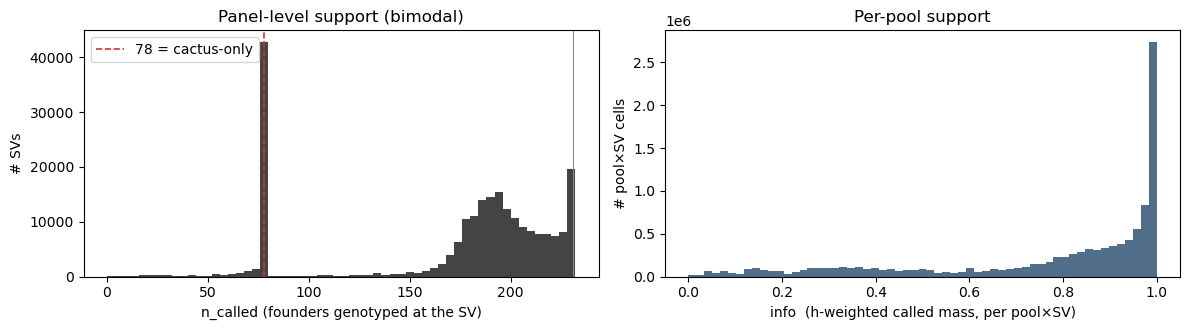

In [2]:
# n_called distribution: the bimodality is the panel split. SVs callable ONLY in the
# 78 cactus assemblies (PanGenie returns ./. for them) pile up at n_called ~ 78.
fig, ax = plt.subplots(1, 2, figsize=(12, 3.4))
ax[0].hist(nc, bins=np.arange(0, 233, 4), color="#444")
ax[0].axvline(78, color="#c33", lw=1.2, ls="--", label="78 = cactus-only")
ax[0].axvline(231, color="#888", lw=.8)
ax[0].set_xlabel("n_called (founders genotyped at the SV)")
ax[0].set_ylabel("# SVs"); ax[0].set_title("Panel-level support (bimodal)"); ax[0].legend()
# per-pool info distribution (pooled over the subset) — the per-sample support
ax[1].hist(info.ravel(), bins=np.linspace(0, 1, 60), color="#357", alpha=.85)
ax[1].set_xlabel("info  (h-weighted called mass, per pool×SV)")
ax[1].set_ylabel("# pool×SV cells"); ax[1].set_title("Per-pool support")
plt.tight_layout(); plt.show()

## Saturation: how many SVs survive each `n_called` cut

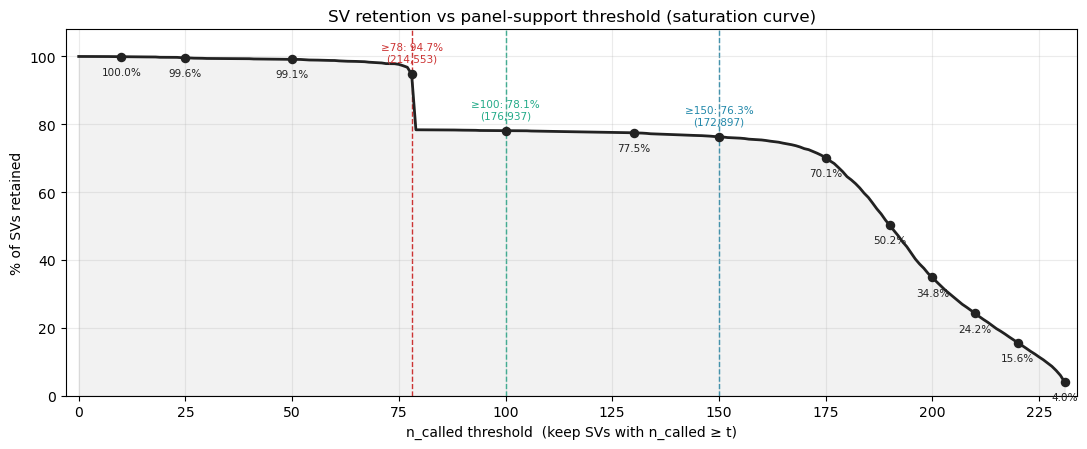

The cliff at ~78–100 is the cactus-only mode (~20% of SVs) leaving.
retention by threshold: ≥10:100.0%  ≥25:99.6%  ≥50:99.1%  ≥78:94.7%  ≥100:78.1%  ≥130:77.5%  ≥150:76.3%  ≥175:70.1%  ≥190:50.2%  ≥200:34.8%  ≥210:24.2%  ≥220:15.6%  ≥231:4.0%


In [3]:
# THE saturation curve: SVs retained vs n_called threshold (drop SVs with n_called < t).
thr = np.arange(0, 232)
retained = np.array([(nc >= t).sum() for t in thr])
frac = retained / N
fig, ax = plt.subplots(figsize=(11, 4.6))
ax.plot(thr, 100 * frac, color="#222", lw=2, zorder=2)
ax.fill_between(thr, 0, 100 * frac, color="#222", alpha=.06)
# candidate cuts (dashed verticals, emphasized)
for t, c in [(78, "#c33"), (100, "#2a8"), (150, "#28a")]:
    ax.axvline(t, color=c, lw=1, ls="--", zorder=1)
# read-off points all along the curve
marks = [10, 25, 50, 78, 100, 130, 150, 175, 190, 200, 210, 220, 231]
mt = np.array(marks); mf = np.array([100*(nc >= t).mean() for t in marks])
ax.scatter(mt, mf, s=34, color="#222", zorder=3)
for t, f in zip(mt, mf):
    above = t in (78, 100, 150)         # candidate cuts: label above with count
    txt = (f"≥{t}: {f:.1f}%\n({(nc>=t).sum():,})" if above else f"{f:.1f}%")
    ax.annotate(txt, (t, f), fontsize=7.5, ha="center",
                color={78:"#c33",100:"#2a8",150:"#28a"}.get(t, "#222"),
                xytext=(0, 9 if above else -13), textcoords="offset points")
ax.set_xlabel("n_called threshold  (keep SVs with n_called ≥ t)")
ax.set_ylabel("% of SVs retained")
ax.set_title("SV retention vs panel-support threshold (saturation curve)")
ax.set_xticks(range(0, 232, 25))
ax.set_ylim(0, 108); ax.set_xlim(-3, 234); ax.grid(alpha=.25)
plt.tight_layout(); plt.show()
print("The cliff at ~78–100 is the cactus-only mode (~20% of SVs) leaving.")
print("retention by threshold: " +
      "  ".join(f"≥{t}:{100*(nc>=t).mean():.1f}%" for t in marks))

## What gets lost — by SV size and founding MAF

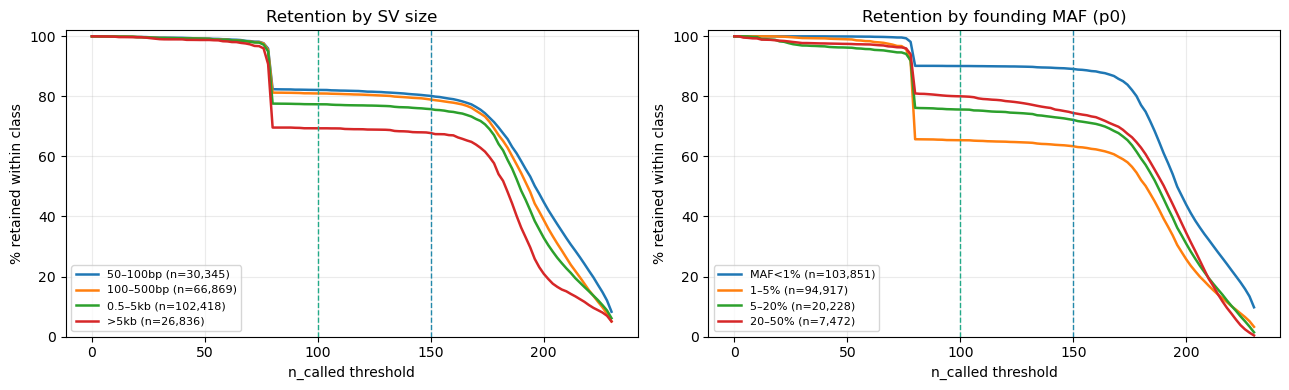

In [4]:
# WHAT do we lose? Retention vs threshold, split by SV size and by MAF — to check we
# are dropping structurally-undercalled SVs, not preferentially the common/large
# (signal-bearing) ones.
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
thr = np.arange(0, 232, 2)
size_bins = [(50, 100), (100, 500), (500, 5000), (5000, 10**9)]
size_lab = ["50–100bp", "100–500bp", "0.5–5kb", ">5kb"]
for (lo, hi), lab in zip(size_bins, size_lab):
    m = (size >= lo) & (size < hi); tot = m.sum()
    ax[0].plot(thr, [100*((nc >= t) & m).sum()/tot for t in thr], lw=1.8,
               label=f"{lab} (n={tot:,})")
ax[0].set_title("Retention by SV size"); ax[0].legend(fontsize=8)
maf_bins = [(0, .01), (.01, .05), (.05, .2), (.2, .5)]
maf_lab = ["MAF<1%", "1–5%", "5–20%", "20–50%"]
for (lo, hi), lab in zip(maf_bins, maf_lab):
    m = (maf >= lo) & (maf < hi); tot = m.sum()
    if tot == 0: continue
    ax[1].plot(thr, [100*((nc >= t) & m).sum()/tot for t in thr], lw=1.8,
               label=f"{lab} (n={tot:,})")
ax[1].set_title("Retention by founding MAF (p0)"); ax[1].legend(fontsize=8)
for a in ax:
    a.axvline(100, color="#2a8", lw=1, ls="--"); a.axvline(150, color="#28a", lw=1, ls="--")
    a.set_xlabel("n_called threshold"); a.set_ylabel("% retained within class")
    a.set_ylim(0, 102); a.grid(alpha=.25)
plt.tight_layout(); plt.show()

## Per-pool `info` mask → matrix missingness (+ coverage confounding)

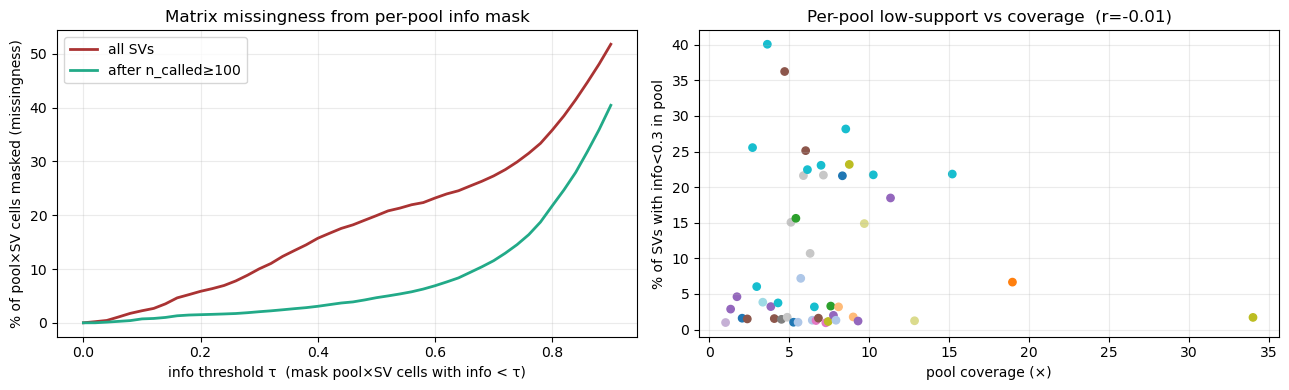

In [5]:
# Per-pool info layer: if we NaN-mask any pool×SV cell with info < tau, how much of the
# matrix goes missing? Shown for the raw SV set and AFTER an n_called≥100 prefilter
# (which removes most low-info cells, since info and n_called correlate at 0.95).
taus = np.linspace(0, 0.9, 46)
keep100 = nc >= 100
miss_raw  = [float(np.mean(info < t)) for t in taus]
miss_pre  = [float(np.mean(info[:, keep100] < t)) for t in taus]
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(taus, 100*np.array(miss_raw), color="#a33", lw=2, label="all SVs")
ax[0].plot(taus, 100*np.array(miss_pre), color="#2a8", lw=2, label="after n_called≥100")
ax[0].set_xlabel("info threshold τ  (mask pool×SV cells with info < τ)")
ax[0].set_ylabel("% of pool×SV cells masked (missingness)")
ax[0].set_title("Matrix missingness from per-pool info mask"); ax[0].legend(); ax[0].grid(alpha=.25)
# info-vs-coverage: is per-pool support confounded with coverage (→ site)? If yes, an
# unmasked low-info cell can fake a climate signal.
med_info = np.median(info, axis=1)
lowfrac = np.mean(info < 0.3, axis=1)
ax[1].scatter(cov, 100*lowfrac, c=site, cmap="tab20", s=28)
ax[1].set_xlabel("pool coverage (×)"); ax[1].set_ylabel("% of SVs with info<0.3 in pool")
r = np.corrcoef(cov, lowfrac)[0, 1]
ax[1].set_title(f"Per-pool low-support vs coverage  (r={r:.2f})"); ax[1].grid(alpha=.25)
plt.tight_layout(); plt.show()

## Summary table

In [6]:
# Summary: retention at candidate cuts + resulting matrix missingness for a τ=0.3 info mask.
rows = []
for t in [0, 50, 78, 100, 150, 200]:
    keep = nc >= t
    sub = info[:, keep]
    rows.append(dict(n_called_cut=f"≥{t}", SVs_kept=int(keep.sum()),
                     pct_SVs=round(100*keep.mean(), 1),
                     pct_kept_MAF5plus=round(100*(keep & (maf>=.05)).sum()/max((maf>=.05).sum(),1), 1),
                     miss_at_info0p3=round(100*float(np.mean(sub < 0.3)), 1)))
pd.DataFrame(rows)

,n_called_cut,SVs_kept,pct_SVs,pct_kept_MAF5plus,miss_at_info0p3
0,≥0,226468,100.0,100.0,10.0
1,≥50,224531,99.1,96.6,9.4
2,≥78,214553,94.7,92.5,7.8
3,≥100,176937,78.1,76.8,2.1
4,≥150,172897,76.3,72.8,1.7
5,≥200,78873,34.8,31.9,0.5


## Reading this

- **`n_called ≥ 100`** drops the cactus-only mode (~20% of SVs, the spike at ~78) and
  the very-low tail, keeping ~78% of SVs — and it keeps the **common, large** SVs (the
  signal-bearing classes) almost fully (see the size/MAF panels).
- The **per-pool `info` mask** then handles residual cells where a *specific* pool's
  ancestry is on the uncalled founders. After the `n_called≥100` prefilter the extra
  missingness is small (info and n_called correlate 0.95).
- Watch the **info-vs-coverage** panel: if low support correlates with coverage (which
  tracks site), unmasked low-info cells can manufacture a climate association — the
  argument for keeping the per-pool mask, not just the panel cut.

**Not fixed here:** the rare-SV identical-trajectory artifact (Chr3 clusters) is *well
supported* (n_called≈191) — it needs a MAF filter + haploblock collapse, not a support cut.
